# GOES imagery — explore

**Dataset:** NOAA **ABI-L2-MCMIPC** (multi-band cloud & moisture imagery, CONUS
sector) — all 16 ABI bands per ~60 MB NetCDF, **8 frames/day (full UTC day,
00–21 UTC at 3-hour gaps)**, pulled from public S3 by `floodlens.download.goes` to
`/mnt/disk4/goes-data/GOES{16|19}/YYYY/MM/DD/`. GOES-16 through 2025-04-06,
GOES-19 after.

This notebook explores the imagery on its own: what's on disk, what one frame
looks like (per band, true colour), and a single frame on an interactive map.
The combined clouds + floods + lightning time-lapse lives in
[`goes_vs_floods.ipynb`](goes_vs_floods.ipynb).

## Helpers — run this cell once

In [1]:
# ---------------------------------------------------------------------------
# Self-contained helpers — run this cell once.
# File discovery, band access, static previews, and a single-frame folium map.
# ---------------------------------------------------------------------------
import base64
import io
from datetime import date
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import rioxarray  # noqa: F401  (registers the .rio accessor)
import xarray as xr
from folium.raster_layers import ImageOverlay
from PIL import Image

# GOES imagery lives on the data drive (override per call with data_dir=)
DATA_DIR = Path("/mnt/disk4/goes-data")


# ---- file discovery & selection ----
def _scan_token(p):
    for part in p.name.split("_"):
        if part.startswith("s") and part[1:].isdigit():
            return part
    return p.name


def scan_time(p):
    t = _scan_token(p)
    if t.startswith("s") and len(t) >= 12:
        return f"{t[8:10]}:{t[10:12]} UTC"
    return "??:??"


def find_files(dt, data_dir=DATA_DIR):
    pat = f"*/{dt.year}/{dt.month:02d}/{dt.day:02d}/*.nc"
    return sorted(data_dir.glob(pat), key=_scan_token)


def open_goes(dt, file_index=0, data_dir=DATA_DIR):
    """List the files for a date and open one (default the first/only)."""
    files = find_files(dt, data_dir)
    if not files:
        raise FileNotFoundError(f"No .nc files for {dt} under {data_dir}")
    for i, p in enumerate(files):
        arrow = "->" if i == file_index else "  "
        print(f"{arrow} [{i}] {scan_time(p)}  {p.name}")
    return xr.open_dataset(files[file_index], decode_times=False)


# ---- band access & scaling ----
def cmi(ds, n):
    """The CMI_C<n> DataArray (decoded reflectance or brightness temperature)."""
    return ds[f"CMI_C{n:02d}"]


def _is_bt(da):
    return str(da.attrs.get("units", "")).strip().upper().startswith("K")


def _cmap(da):
    return "gray_r" if _is_bt(da) else "gray"  # IR: cold cloud tops = white


def _stretch(a, vmin=None, vmax=None):
    lo = np.nanpercentile(a, 2) if vmin is None else vmin
    hi = np.nanpercentile(a, 98) if vmax is None else vmax
    return float(lo), float(hi)


def _norm(a, lo, hi):
    return np.clip((a - lo) / (hi - lo), 0, 1) if hi > lo else np.zeros_like(a)


# ---- crop on the native geostationary grid ----
def _geos(ds):
    return pyproj.CRS.from_cf(dict(ds["goes_imager_projection"].attrs))


def crop_lonlat(ds, lon_min, lon_max, lat_min, lat_max):
    """Subset to a lon/lat box (degrees) before plotting/mapping."""
    h = ds["goes_imager_projection"].attrs["perspective_point_height"]
    tf = pyproj.Transformer.from_crs("EPSG:4326", _geos(ds), always_xy=True)
    lons = [lon_min, lon_max, lon_min, lon_max]
    lats = [lat_min, lat_min, lat_max, lat_max]
    xs, ys = tf.transform(lons, lats)
    xs = np.array(xs) / h
    ys = np.array(ys) / h
    xs, ys = xs[np.isfinite(xs)], ys[np.isfinite(ys)]
    if xs.size == 0 or ys.size == 0:
        raise ValueError("box is off the Earth disk for this satellite")
    return ds.sel(x=slice(xs.min(), xs.max()), y=slice(ys.max(), ys.min()))


def crop_pixels(ds, x0, x1, y0, y1):
    """Subset by pixel index (x: 0..2500 W->E, y: 0..1500 N->S)."""
    return ds.isel(x=slice(x0, x1), y=slice(y0, y1))


# ---- static (matplotlib) previews ----
def show_band(ds, n, cmap=None, vmin=None, vmax=None, figsize=(11, 7)):
    da = cmi(ds, n)
    a = da.values
    lo, hi = _stretch(a, vmin, vmax)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(a, cmap=cmap or _cmap(da), vmin=lo, vmax=hi,
                   interpolation="nearest", origin="upper", aspect="equal")
    units = da.attrs.get("units", "")
    ax.set_title(f"Band {n}: {da.attrs.get('long_name', '')} ({units})\n"
                 f"{a.shape[1]}x{a.shape[0]} px")
    fig.colorbar(im, ax=ax, shrink=0.7, label=units)
    fig.tight_layout()
    return fig


def show_rgb(ds, bands=(2, 3, 1), gamma=2.2, figsize=(11, 7)):
    chans = []
    for b in bands:
        a = cmi(ds, b).values
        chans.append(_norm(a, *_stretch(a)))
    rgb = np.clip(np.nan_to_num(np.dstack(chans), nan=0.0) ** (1 / gamma), 0, 1)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(rgb, interpolation="nearest", origin="upper", aspect="equal")
    ax.set_title(f"RGB = bands {tuple(bands)} (R, G, B)\n"
                 f"{rgb.shape[1]}x{rgb.shape[0]} px")
    fig.tight_layout()
    return fig


# ---- reproject geostationary -> lat/lon, then RGBA for a web-map overlay ----
def reproject_bands(ds, bands):
    """Reproject bands to EPSG:4326.

    Returns (DataArray with dim 'band', bounds=[[south, west], [north, east]]),
    oriented north-up / west-left so it drops straight onto a Leaflet overlay.
    """
    h = ds["goes_imager_projection"].attrs["perspective_point_height"]
    da = xr.concat([cmi(ds, n).reset_coords(drop=True) for n in bands], dim="band")
    da = da.assign_coords(x=ds["x"] * h, y=ds["y"] * h)
    da = da.rio.write_crs(_geos(ds)).rio.set_spatial_dims(x_dim="x", y_dim="y")
    da = da.rio.reproject("EPSG:4326", nodata=np.nan)
    da = da.sortby("y", ascending=False).sortby("x")
    minx, miny, maxx, maxy = da.rio.bounds()
    return da, [[miny, minx], [maxy, maxx]]


def _rgba_single(a, cmap, lo, hi):
    finite = np.isfinite(a)
    sm = plt.cm.ScalarMappable(norm=plt.Normalize(lo, hi), cmap=cmap)
    rgba = sm.to_rgba(np.nan_to_num(a, nan=lo), bytes=True)
    rgba[..., 3] = np.where(finite, 255, 0).astype("uint8")
    return rgba


def _rgba_rgb(arr3, gamma):
    chans, alpha = [], np.ones(arr3.shape[1:], dtype=bool)
    for a in arr3:
        chans.append(_norm(a, *_stretch(a)))
        alpha = alpha & np.isfinite(a)
    rgb = np.nan_to_num(np.clip(np.dstack(chans) ** (1 / gamma), 0, 1))
    a8 = np.where(alpha, 255, 0).astype("uint8")
    return np.dstack([(rgb * 255).astype("uint8"), a8])


def _data_uri(rgba):
    buf = io.BytesIO()
    Image.fromarray(rgba, mode="RGBA").save(buf, format="PNG")
    return "data:image/png;base64," + base64.b64encode(buf.getvalue()).decode()


def show_on_map(ds, band=13, rgb=None, cmap=None, vmin=None, vmax=None,
                gamma=2.2, opacity=0.85):
    """Overlay a GOES band (or RGB triple) on a scroll-zoom folium map.

    The image is reprojected to lat/lon so it aligns with the basemap. Use the
    layer control (top-right) to switch basemaps or toggle the overlay.
    """
    if rgb is not None:
        da_ll, bounds = reproject_bands(ds, list(rgb))
        img = _rgba_rgb(da_ll.values, gamma)
        label = f"GOES RGB {tuple(rgb)}"
    else:
        da_ll, bounds = reproject_bands(ds, [band])
        a = da_ll.isel(band=0).values
        lo, hi = _stretch(a, vmin, vmax)
        img = _rgba_single(a, cmap or _cmap(cmi(ds, band)), lo, hi)
        label = f"GOES band {band}"
    (s, w), (n, e) = bounds
    m = folium.Map(location=[(s + n) / 2, (w + e) / 2], zoom_start=5,
                   tiles="OpenStreetMap")
    folium.TileLayer("CartoDB positron", name="light").add_to(m)
    folium.TileLayer(
        tiles=("https://server.arcgisonline.com/ArcGIS/rest/services/"
               "World_Imagery/MapServer/tile/{z}/{y}/{x}"),
        attr="Esri World Imagery", name="satellite",
    ).add_to(m)
    ImageOverlay(_data_uri(img), bounds=bounds, opacity=opacity,
                 name=label).add_to(m)
    folium.LayerControl().add_to(m)
    m.fit_bounds(bounds)
    return m

## 1. What's on disk

In [2]:
files = list(DATA_DIR.glob("GOES*/*/*/*/*.nc"))
info = pd.DataFrame([
    {"satellite": p.parts[-5], "year": int(p.parts[-4]),
     "day": "/".join(p.parts[-4:-1]), "bytes": p.stat().st_size}
    for p in files
])
print(f"{len(files):,} files | {info['day'].nunique():,} days | "
      f"{info['bytes'].sum() / 1024 ** 3:,.0f} GB")
(info.groupby(["satellite", "year"])
     .agg(files=("bytes", "size"), days=("day", "nunique"),
          GB=("bytes", lambda b: b.sum() / 1024 ** 3)).round(1))

21,698 files | 2,718 days | 1,034 GB


files  days     GB
satellite year                    
GOES16    2019   2915   365  147.2
          2020   2922   366  147.3
          2021   2911   365  146.7
          2022   2911   365  145.8
          2023   2915   365  133.8
          2024   2917   366  129.0
          2025    767    96   32.2
GOES19    2025   2152   269   95.9
          2026   1288   161   56.2

## 2. Choose a date & file

In [3]:
DATE = date(2019, 6, 15)
ds = open_goes(DATE, file_index=4)

   [0] 00:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191660001501_e20191660004273_c20191660004388.nc
   [1] 03:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191660301502_e20191660304274_c20191660304386.nc
   [2] 06:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191660601503_e20191660604276_c20191660604387.nc
   [3] 09:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191660901503_e20191660904276_c20191660904385.nc
-> [4] 12:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191661201504_e20191661204277_c20191661204399.nc
   [5] 15:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191661501504_e20191661504277_c20191661504399.nc
   [6] 18:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191661801505_e20191661804278_c20191661804398.nc
   [7] 21:01 UTC  OR_ABI-L2-MCMIPC-M6_G16_s20191662101506_e20191662104279_c20191662104397.nc


## 3. Quick static look

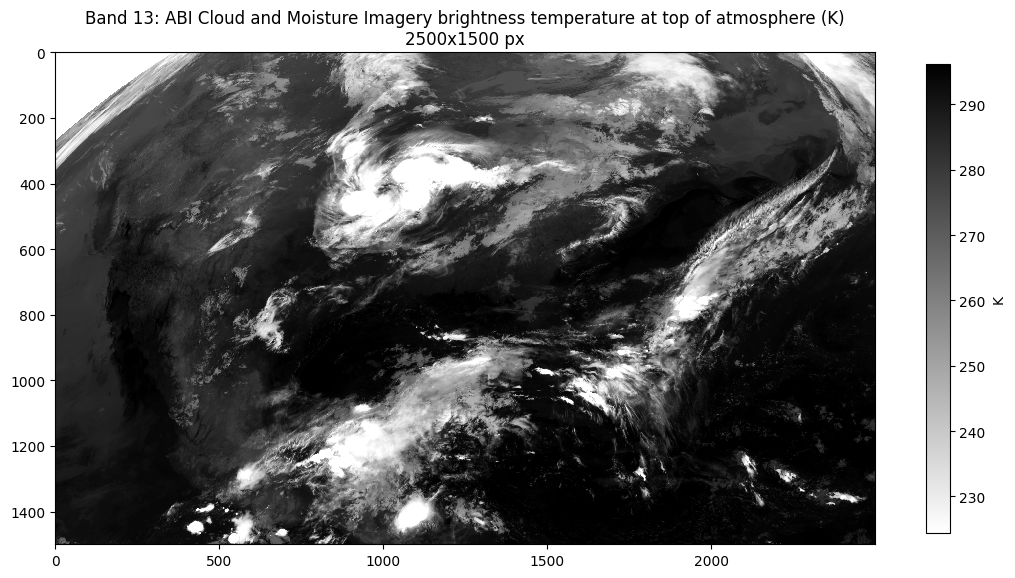

In [4]:
show_band(ds, 13);   # clean IR: cold cloud tops bright. Try 2 (red), 8 (water vapor), ...

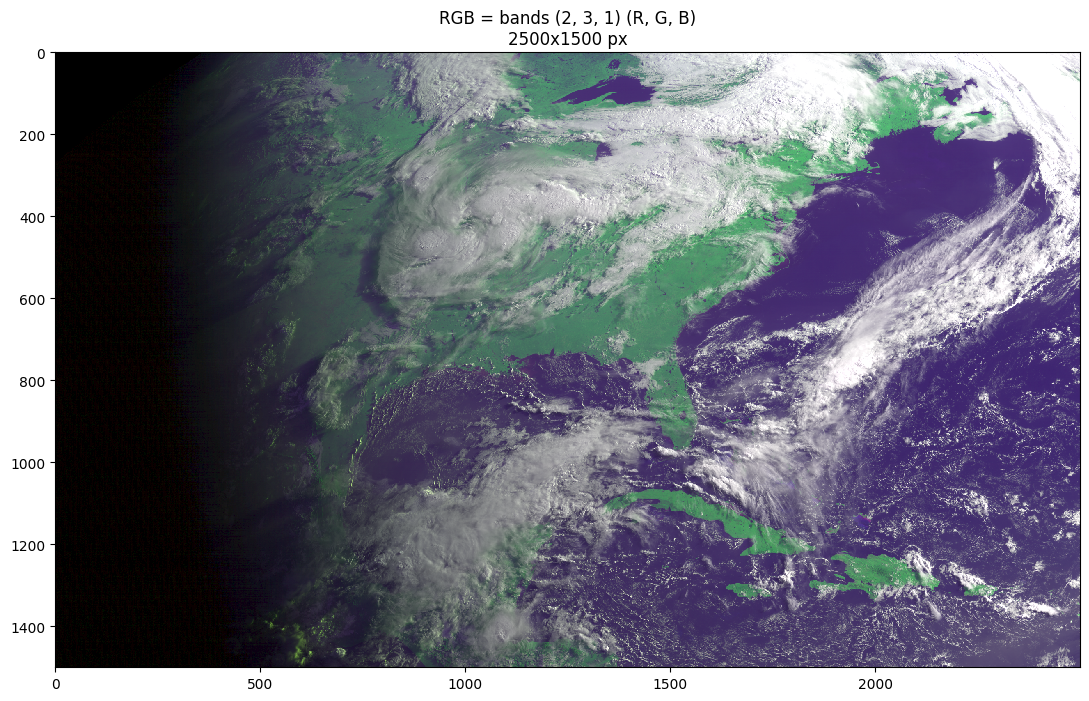

In [5]:
show_rgb(ds, (2, 3, 1));   # true color (daytime)

## 4. Interactive map — scroll to zoom, drag to pan


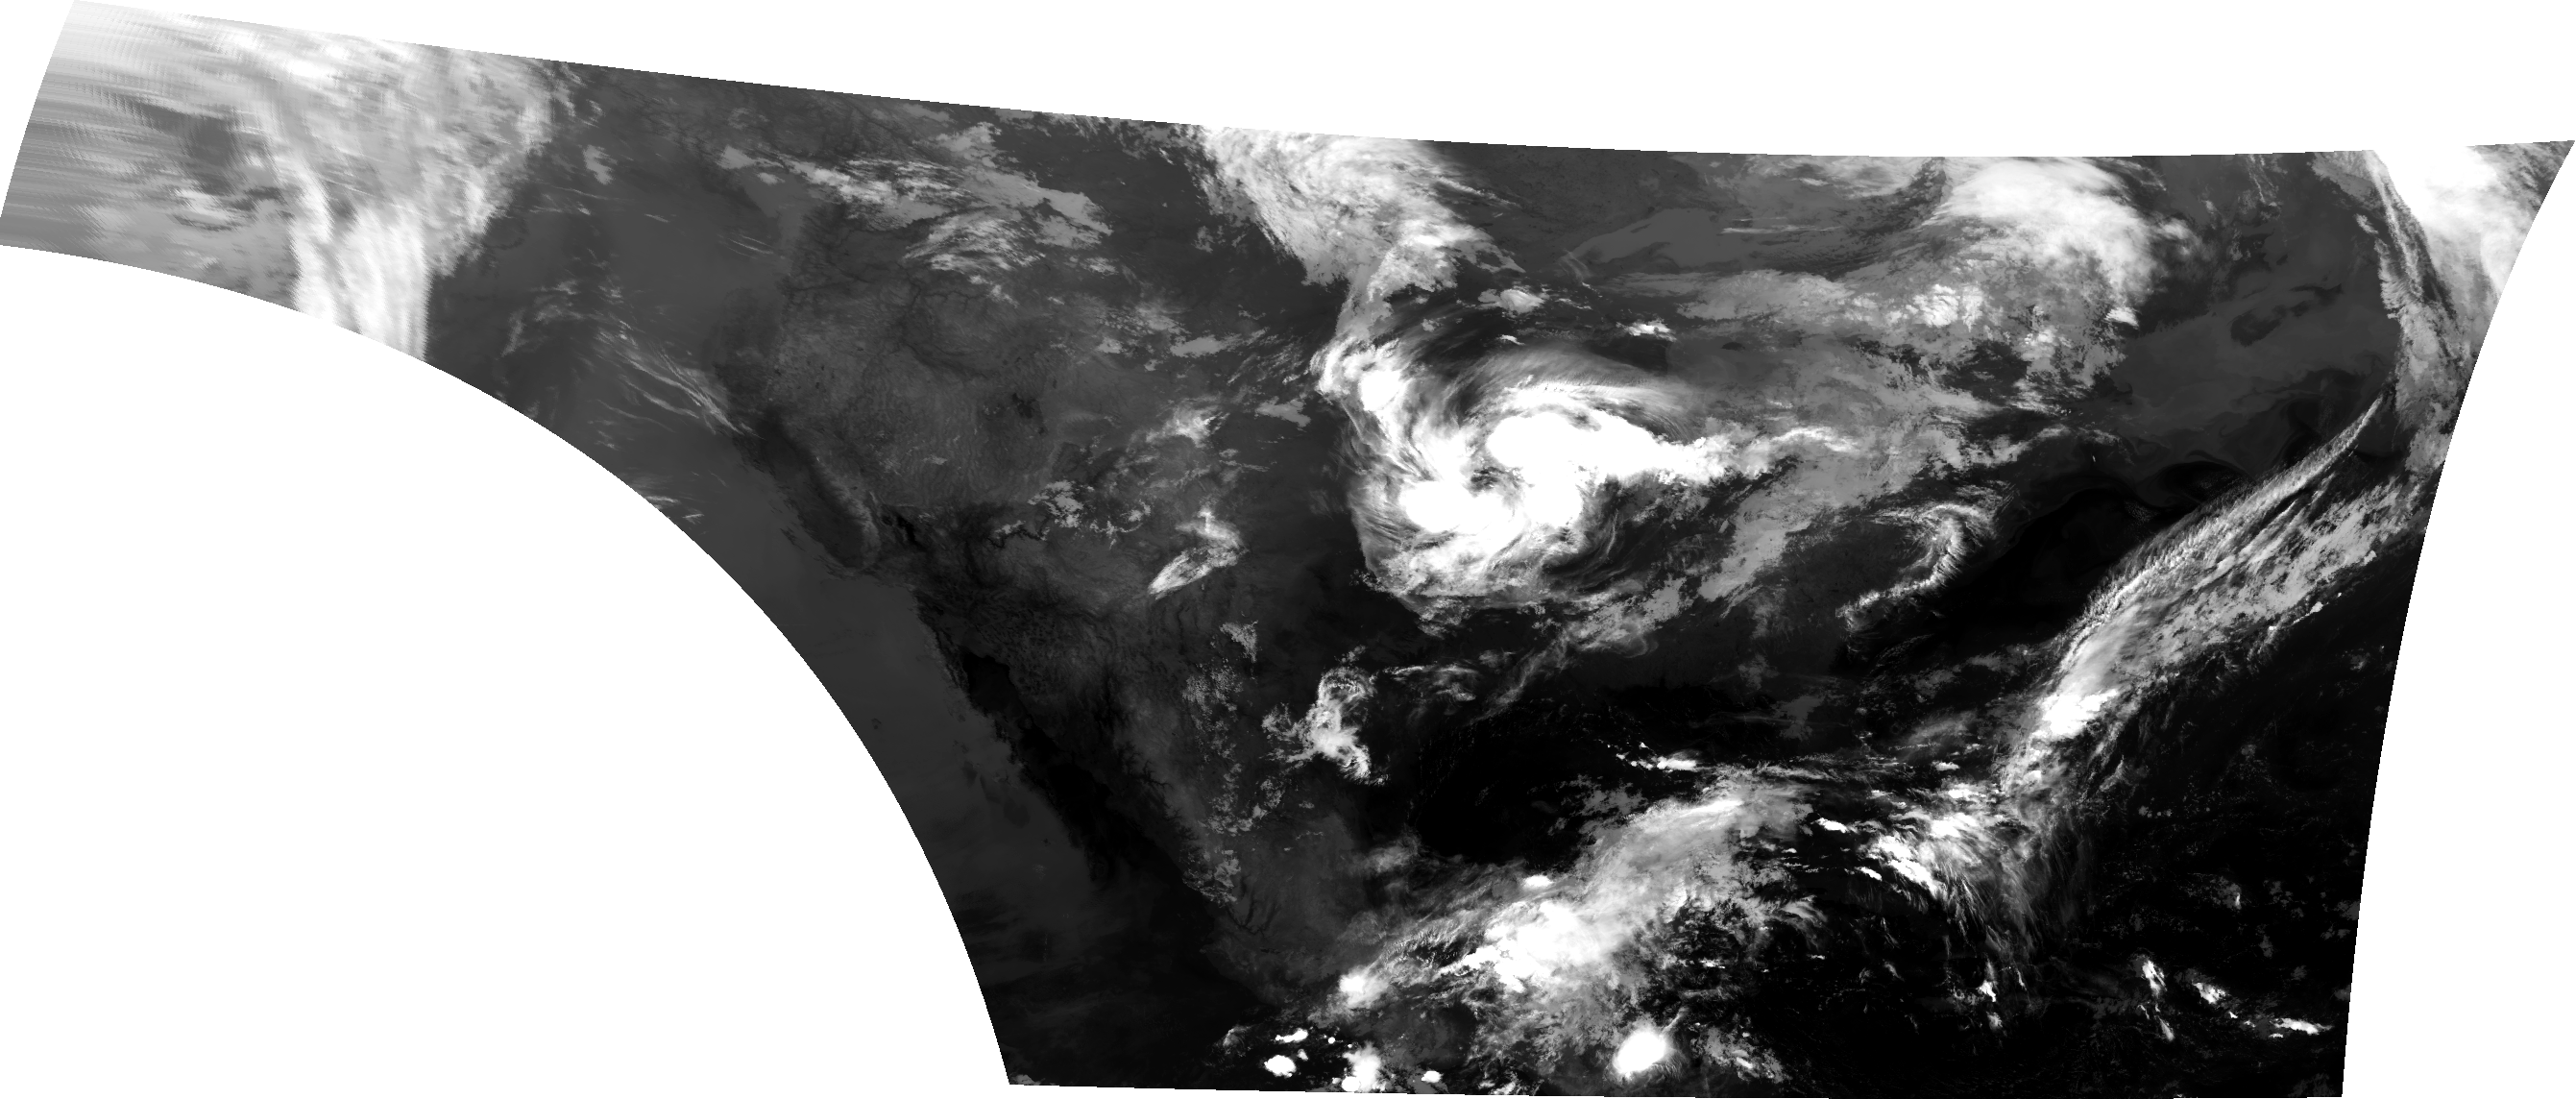

In [6]:
show_on_map(ds, band=13, opacity=0.85)

## 5. Focus a region


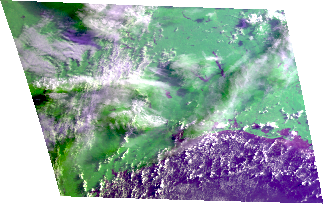

In [7]:
sub = crop_lonlat(ds, lon_min=-98, lon_max=-92, lat_min=28, lat_max=33)
show_on_map(sub, rgb=(2, 3, 1))

## Band cheat-sheet

| band | wavelength | what it shows |
|---|---|---|
| 1–2 | 0.47 / 0.64 µm | visible blue / red (daytime reflectance) |
| 3 | 0.86 µm | veggie near-IR (used as pseudo-green) |
| 7 | 3.9 µm | shortwave IR — fires, low cloud at night |
| 8–10 | 6.2–7.3 µm | **water vapour** (upper / mid / low) |
| 13 | 10.3 µm | **clean IR window** — cloud-top temperature, day & night |
| 14–15 | 11.2 / 12.3 µm | IR window / dirty window (split-window moisture) |

`CMI_C01..C06` are reflectances (0–1), `C07..C16` brightness temperatures (K).
IR bands display with `gray_r` so cold (high) cloud tops read as bright.